<b><font color="#1f4e79" size="7">
Notebook 2:
<br></font></b>

<b><font color="#1f4e79" size="6">
Functional Connectivity Estimation
</font></b>

<hr>



This notebook implements a complete pipeline for:

- Loading ROI time-series extracted from the AAL3 atlas
- Computing static functional connectivity matrices using Pearson correlation and partial correlation
- Performing quality control and visualizing connectivity matrices
- Converting connectivity matrices into upper-triangular feature vectors
- Combining individual feature vectors into machine learning feature matrices
- Saving all outputs for downstream feature selection and classification

# Setup

## Install & Imports

In [1]:
import zipfile
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

!pip install nilearn --quiet
from nilearn.connectome import ConnectivityMeasure

## Download extracted ROI time series

The ROI time-series extracted in Notebook 1 are used as input for functional connectivity analysis.

The dataset contains:
- 72 participants
- 100 timepoints per participant
- 166 AAL3 regions

The files are stored as compressed NumPy arrays.

In [2]:
!wget -O /content/AAL3_timeseries_all_subjects.zip \
"https://raw.githubusercontent.com/negareri/fMRI-Connectome-MDD/main/outputs/notebook1/AAL3_timeseries_all_subjects.zip"

with zipfile.ZipFile(
    "/content/AAL3_timeseries_all_subjects.zip",
    "r"
) as zip_ref:
    zip_ref.extractall("/content/timeseries")

--2026-07-21 22:31:15--  https://raw.githubusercontent.com/negareri/fMRI-Connectome-MDD/main/outputs/notebook1/AAL3_timeseries_all_subjects.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4449977 (4.2M) [application/zip]
Saving to: ‘/content/AAL3_timeseries_all_subjects.zip’

/content/AAL3_times 100%[===================>]   4.24M  --.-KB/s    in 0.08s   

2026-07-21 22:31:15 (52.5 MB/s) - ‘/content/AAL3_timeseries_all_subjects.zip’ saved [4449977/4449977]



# Pearson Functional Connectivity

Functional connectivity (FC) quantifies the statistical dependency between the BOLD signals of different brain regions. The most widely used measure is the **Pearson correlation coefficien**t, which evaluates the strength of the linear relationship between the time series of two ROIs.

For two ROI time series $x$ and $y$, the Pearson correlation coefficient is computed as:

$$
r_{xy}=
\frac{\sum_{t=1}^{T}(x_t-\bar{x})(y_t-\bar{y})}
{\sqrt{\sum_{t=1}^{T}(x_t-\bar{x})^2}
\sqrt{\sum_{t=1}^{T}(y_t-\bar{y})^2}}
$$

where:

- $x_t$ and $y_t$ are the BOLD signal values at timepoint $t$.
- $\bar{x}$ and $\bar{y}$ are the mean signals of the two ROIs.
- $T$ is the number of timepoints.

In [4]:
timeseries_dir = Path("/content/timeseries")
output_dir = Path("/content/pearson_fc")

output_dir.mkdir(parents=True, exist_ok=True)

for ts_file in sorted(timeseries_dir.glob("sub-*_timeseries.npy")):

    subject = ts_file.stem.replace("_timeseries", "")

    timeseries = np.load(ts_file)

    pearson_fc = np.corrcoef(timeseries, rowvar=False)

    np.save(
        output_dir / f"{subject}_pearson_fc.npy",
        pearson_fc
    )

print(f"Saved {len(list(output_dir.glob('*.npy')))} Pearson FC matrices.")

Saved 72 Pearson FC matrices.


## Quality Control and Visualization

- Verify that all generated matrices have the expected dimensions (166 × 166).

- Visualize connectivity matrices from two representative subjects as a qualitative quality check.

✓ All 72 Pearson FC matrices have shape (166, 166).


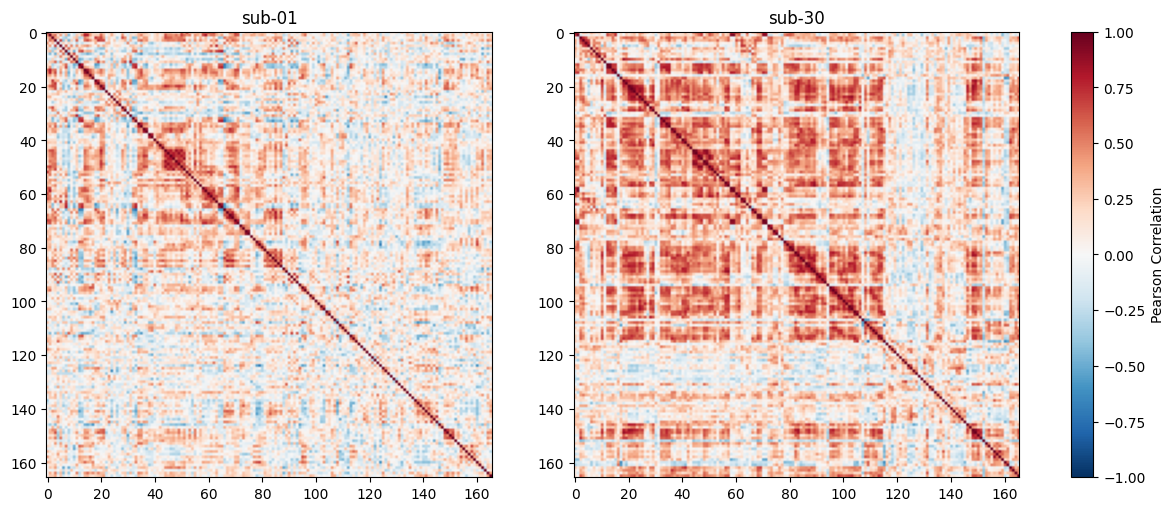

In [5]:
fc_dir = Path("/content/pearson_fc")

expected_shape = (166, 166)

invalid = []
for fc_file in sorted(fc_dir.glob("sub-*_pearson_fc.npy")):

    fc = np.load(fc_file)

    if fc.shape != expected_shape:
        invalid.append((fc_file.name, fc.shape))

if len(invalid) == 0:
    print(f"✓ All {len(list(fc_dir.glob('*.npy')))} Pearson FC matrices have shape {expected_shape}.")
else:
    print("Invalid matrices:")
    for name, shape in invalid:
        print(f"{name}: {shape}")


subject1 = "sub-01"
subject2 = "sub-30"

fc1 = np.load(fc_dir / f"{subject1}_pearson_fc.npy")
fc2 = np.load(fc_dir / f"{subject2}_pearson_fc.npy")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

im = axes[0].imshow(fc1, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_title(subject1)

axes[1].imshow(fc2, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_title(subject2)

fig.colorbar(im, ax=axes, location="right", label="Pearson Correlation")

plt.show()

## Converting Connectivity Matrices to Feature Vectors

Machine learning algorithms require one-dimensional feature vectors rather than square connectivity matrices.

Since functional connectivity matrices are symmetric and the diagonal contains self-connections only, we retain the upper triangular part of each matrix (excluding the diagonal), resulting in 13,695 unique connectivity features per subject.

In [6]:
fc_dir = Path("/content/pearson_fc")
feature_dir = Path("/content/pearson_features")

feature_dir.mkdir(parents=True, exist_ok=True)

for fc_file in sorted(fc_dir.glob("sub-*_pearson_fc.npy")):

    subject = fc_file.stem.replace("_pearson_fc", "")

    fc = np.load(fc_file)

    feature_vector = fc[np.triu_indices_from(fc, k=1)]

    np.save(
        feature_dir / f"{subject}_pearson_features.npy",
        feature_vector
    )


expected_shape = (166 * 165 // 2,)

invalid = []

for feature_file in sorted(feature_dir.glob("sub-*_pearson_features.npy")):

    feature = np.load(feature_file)

    if feature.shape != expected_shape:
        invalid.append((feature_file.name, feature.shape))

if len(invalid) == 0:
    print(
        f"✓ All {len(list(feature_dir.glob('*.npy')))} feature vectors "
        f"have shape {expected_shape}."
    )
else:
    print("Invalid feature vectors:")
    for name, shape in invalid:
        print(f"{name}: {shape}")

✓ All 72 feature vectors have shape (13695,).


## Exporting Results

In [7]:
output_dir = Path("/content/pearson_fc")
zip_path = "/content/pearson_fc.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in output_dir.glob("*.npy"):
        zipf.write(file, arcname=file.name)

print("Pearson FC zipped.")

output_dir = Path("/content/pearson_features")
zip_path = "/content/pearson_features.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in output_dir.glob("*.npy"):
        zipf.write(file, arcname=file.name)

print("Pearson feature vectors zipped.")

Pearson FC zipped.
Pearson feature vectors zipped.


## Combining Feature Vectors into a Feature Matrix

Machine learning models require a single feature matrix where each row represents one subject and each column represents one connectivity feature. The individual feature vectors from all subjects are combined into a matrix with dimensions:

$$
N_{subjects} \times N_{features}
$$

For this dataset: $$72 \times 13695$$

In [8]:
feature_dir = Path("/content/pearson_features")

feature_files = sorted(feature_dir.glob("sub-*_pearson_features.npy"))

X_pearson = np.vstack([np.load(file) for file in feature_files])

subjects = [
    file.stem.replace("_pearson_features", "")
    for file in feature_files
]

np.save("/content/X_pearson.npy", X_pearson)

print(f"Feature matrix shape: {X_pearson.shape}")

Feature matrix shape: (72, 13695)


In [15]:
pd.DataFrame(X_pearson)

,0,1,2,3,4,5,6,7,8,9,...,13685,13686,13687,13688,13689,13690,13691,13692,13693,13694
0,0.482411,0.282625,0.143000,0.443525,0.117485,0.274844,0.172868,-0.085413,-0.020191,-0.206195,...,0.202763,-0.033053,0.273778,0.173788,-0.214099,0.298831,0.201682,0.019076,0.124983,0.407135
1,0.490107,0.469451,0.471425,0.402633,-0.028338,0.510429,0.014013,0.397279,0.148680,0.513559,...,0.292700,0.368130,0.314492,-0.112628,0.019439,-0.047340,0.193037,0.309126,-0.240409,-0.057789
2,0.589772,0.634195,0.657773,0.644727,0.645139,0.580089,0.562054,0.609600,0.485298,0.476776,...,0.029572,0.197169,0.203980,0.214369,0.709114,0.010948,0.631539,0.082542,0.644354,0.130868
3,0.408319,0.186876,0.369568,0.375025,0.377765,0.552205,0.366582,0.151148,0.039594,0.068952,...,-0.011422,0.258434,0.341535,0.388109,-0.081238,0.210168,0.291835,-0.083640,0.158705,0.061853
4,0.798399,0.335978,0.269087,0.657639,0.449268,0.594633,0.343058,0.690686,0.255089,0.359012,...,0.150968,0.024268,0.267505,0.340591,0.078063,0.075280,-0.092956,-0.053197,-0.149239,-0.160665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,0.624674,0.097967,0.079488,0.295969,0.244928,0.444525,0.266707,0.482682,0.298598,0.497990,...,0.490561,0.365250,0.515058,0.413098,0.324718,0.434938,0.472532,0.247564,0.451995,0.402115
68,0.685031,0.502996,0.399276,0.557558,0.546921,0.612176,0.494090,0.560046,0.429190,0.433812,...,0.034854,0.104843,0.307877,-0.129779,0.575811,0.177870,0.042410,-0.015619,0.013658,0.162335
69,0.539250,0.481886,0.376474,0.387477,0.363724,0.593109,0.571777,0.484355,0.565232,0.267483,...,0.094923,-0.165351,0.059404,-0.169089,0.255512,-0.285024,0.278532,0.073329,0.050814,-0.031754
70,0.564168,0.131705,0.315884,0.314074,0.390419,0.490627,0.307536,0.477410,0.308815,0.221300,...,0.380755,0.135013,-0.201852,-0.324439,0.063198,-0.246584,-0.176989,-0.016554,0.001666,0.315851


# Partial Functional Connectivity

**Partial correlation** estimates the direct statistical relationship between two brain regions while controlling for the influence of all remaining ROIs. Compared with Pearson correlation, it suppresses indirect connections mediated by other regions and therefore provides a sparser estimate of functional connectivity.

For two ROI time series $x$ and $y$, while controlling for a set of variables $Z$, the partial correlation coefficient can be computed as:

$$
r_{xy.z}=
\frac{r_{xy}-r_{xz}r_{yz}}
{\sqrt{(1-r_{xz}^{2})(1-r_{yz}^{2})}}
$$

where:

- $r_{xy}$ is the Pearson correlation between ROI signals $x$ and $y$.
- $r_{xz}$ and $r_{yz}$ represent the correlations between the controlled variables and the two ROI signals.
- $r_{xy.z}$ is the correlation between $x$ and $y$ after removing the influence of the variables in $Z$.

The resulting partial correlation matrix has the same structure as the Pearson FC matrix, with dimensions of $166 \times 166$, where each element represents the direct statistical association between a pair of brain regions after accounting for the remaining regions.

In [9]:
timeseries_dir = Path("/content/timeseries")
output_dir = Path("/content/partial_fc")

output_dir.mkdir(parents=True, exist_ok=True)

partial_measure = ConnectivityMeasure(kind="partial correlation")

for ts_file in sorted(timeseries_dir.glob("sub-*_timeseries.npy")):

    subject = ts_file.stem.replace("_timeseries", "")

    timeseries = np.load(ts_file)

    partial_fc = partial_measure.fit_transform([timeseries])[0]

    np.save(
        output_dir / f"{subject}_partial_fc.npy",
        partial_fc
    )

print(f"Saved {len(list(output_dir.glob('*.npy')))} Partial FC matrices.")

Saved 72 Partial FC matrices.


## Quality Control and Visualization

✓ All 72 Partial FC matrices have shape (166, 166).


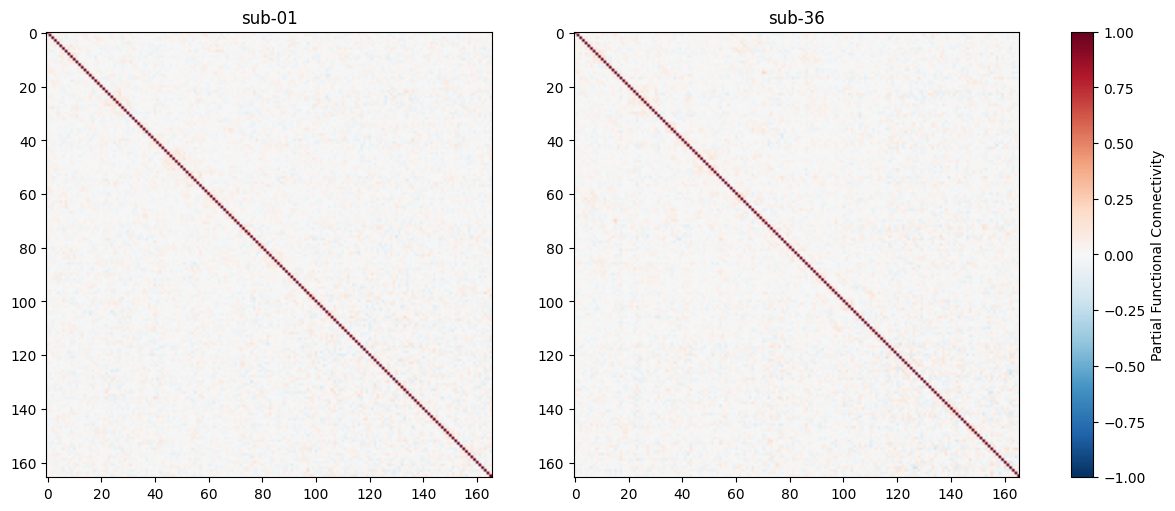

In [10]:
fc_dir = Path("/content/partial_fc")

expected_shape = (166, 166)

invalid = []
for fc_file in sorted(fc_dir.glob("sub-*_partial_fc.npy")):

    fc = np.load(fc_file)

    if fc.shape != expected_shape:
        invalid.append((fc_file.name, fc.shape))

if len(invalid) == 0:
    print(f"✓ All {len(list(fc_dir.glob('*.npy')))} Partial FC matrices have shape {expected_shape}.")
else:
    print("Invalid matrices:")
    for name, shape in invalid:
        print(f"{name}: {shape}")


subject1 = "sub-01"
subject2 = "sub-36"

fc1 = np.load(fc_dir / f"{subject1}_partial_fc.npy")
fc2 = np.load(fc_dir / f"{subject2}_partial_fc.npy")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

im = axes[0].imshow(fc1, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_title(subject1)

axes[1].imshow(fc2, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_title(subject2)

fig.colorbar(im, ax=axes, location="right", label="Partial Functional Connectivity")

plt.show()

## Converting Connectivity Matrices to Feature Vectors

In [11]:
fc_dir = Path("/content/partial_fc")
feature_dir = Path("/content/partial_features")

feature_dir.mkdir(parents=True, exist_ok=True)

for fc_file in sorted(fc_dir.glob("sub-*_partial_fc.npy")):

    subject = fc_file.stem.replace("_partial_fc", "")

    partial_fc = np.load(fc_file)

    feature_vector = partial_fc[np.triu_indices_from(partial_fc, k=1)]

    np.save(
        feature_dir / f"{subject}_partial_features.npy",
        feature_vector
    )


expected_shape = (166 * 165 // 2,)

invalid = []

for feature_file in sorted(feature_dir.glob("sub-*_pearson_features.npy")):

    feature = np.load(feature_file)

    if feature.shape != expected_shape:
        invalid.append((feature_file.name, feature.shape))

if len(invalid) == 0:
    print(
        f"✓ All {len(list(feature_dir.glob('*.npy')))} feature vectors "
        f"have shape {expected_shape}."
    )
else:
    print("Invalid feature vectors:")
    for name, shape in invalid:
        print(f"{name}: {shape}")

✓ All 72 feature vectors have shape (13695,).


## Exporting Results

In [12]:
output_dir = Path("/content/partial_fc")
zip_path = "/content/partial_fc.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in output_dir.glob("*.npy"):
        zipf.write(file, arcname=file.name)

print("Partial FC zipped.")

output_dir = Path("/content/partial_features")
zip_path = "/content/partial_features.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in output_dir.glob("*.npy"):
        zipf.write(file, arcname=file.name)

print("Partial feature vectors zipped.")

Partial FC zipped.
Partial feature vectors zipped.


## Combining Feature Vectors into a Feature Matrix

In [13]:
feature_dir = Path("/content/partial_features")

feature_files = sorted(feature_dir.glob("sub-*_partial_features.npy"))

X_partial = np.vstack([np.load(file) for file in feature_files])

subjects = [
    file.stem.replace("_partial_features", "")
    for file in feature_files
]

np.save("/content/X_partial.npy", X_partial)

print(f"Feature matrix shape: {X_partial.shape}")

Feature matrix shape: (72, 13695)


In [14]:
pd.DataFrame(X_partial)

,0,1,2,3,4,5,6,7,8,9,...,13685,13686,13687,13688,13689,13690,13691,13692,13693,13694
0,0.034464,0.037944,-0.011393,0.064818,-0.009899,0.068499,-0.027193,0.033454,-0.011850,0.009581,...,0.011207,0.048450,0.025970,0.083511,-0.088244,-0.023175,0.007267,0.023579,0.051534,0.087136
1,0.024010,0.025393,0.030577,0.000524,-0.023358,0.036041,0.023072,0.010034,-0.000276,0.029409,...,0.151449,0.048787,0.009752,0.014921,-0.048441,0.031809,0.021484,0.015573,-0.093582,0.039242
2,0.039011,0.055510,0.031989,0.050823,0.024065,0.085411,0.039275,0.071961,-0.006105,0.010104,...,-0.050950,0.053058,0.011491,0.004764,0.086735,-0.054286,0.134776,0.019794,0.040976,0.116537
3,0.030546,0.002793,0.024374,0.016729,0.020153,0.069512,-0.015254,0.000642,-0.013930,-0.003786,...,-0.049196,0.004759,0.026893,0.026101,0.020148,-0.007286,0.030322,-0.040889,-0.006131,0.000258
4,0.059862,0.062729,0.025726,0.065136,0.031120,0.007940,-0.005786,0.034752,0.018629,0.032794,...,0.033504,-0.013385,0.018470,0.041348,0.020883,0.027470,-0.010949,-0.002624,-0.074104,-0.063285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,0.067558,0.014289,0.007291,0.061140,0.013440,0.000084,-0.011353,0.086592,0.010617,0.045777,...,0.036677,0.057402,0.071579,0.036144,-0.044211,0.055303,0.044461,0.044315,0.071222,0.067952
68,0.027545,-0.005048,-0.029673,0.012342,0.003781,0.055773,0.013125,0.037379,-0.026186,0.050274,...,-0.003347,0.016896,0.042706,-0.063250,0.116111,0.026863,-0.026060,-0.035382,-0.119808,0.030370
69,0.041464,0.040240,-0.005171,0.072194,0.049670,0.082640,0.041206,0.020375,0.037586,0.016171,...,0.048353,-0.045310,0.043684,-0.114200,0.133620,-0.042762,0.092192,0.004935,-0.030934,-0.010624
70,0.033057,-0.030831,0.026213,-0.001556,0.030138,0.030362,0.000974,0.069247,0.009311,0.007224,...,0.002204,0.035788,0.011686,-0.070798,-0.027934,0.027536,0.010843,0.035993,-0.035816,0.028609
